In [7]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import pandas as pd



In [19]:
MODEL_PATH = "../src/weights/violence_detector.h5"
DATASET_PATH = "../Training/violence_training_data"


IMG_SIZE = 96
FRAMES_PER_CLIP = 16

model = load_model(MODEL_PATH)

classes = ["NonViolence", "Violence"]


In [20]:
def load_video_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = frame.astype("float32") / 255.0
        frames.append(frame)

    cap.release()
    return frames


def make_clips(frames, clip_len=16):
    clips = []
    for i in range(0, len(frames), clip_len):
        clip = frames[i:i+clip_len]
        if len(clip) == clip_len:
            clips.append(np.array(clip))
    return clips



In [21]:
video_labels = []
video_preds = []

for label in classes:
    folder = os.path.join(DATASET_PATH, label)
    label_value = classes.index(label)

    print(f"\nProcessing folder: {label}")

    for filename in os.listdir(folder):
        if filename.endswith(".mp4"):
            video_path = os.path.join(folder, filename)

            frames = load_video_frames(video_path)
            clips = make_clips(frames, FRAMES_PER_CLIP)

            if len(clips) == 0:
                continue

            clips = np.array(clips)

            preds = model.predict(clips)
            clip_preds = np.argmax(preds, axis=1)

            final_pred = 1 if np.sum(clip_preds) > (len(clip_preds)/2) else 0

            video_labels.append(label_value)
            video_preds.append(final_pred)

y_true = np.array(video_labels)
y_pred = np.array(video_preds)




Processing folder: NonViolence
1/1 [==============================] - 1s 626ms/step

Processing folder: Violence
1/1 [==============================] - 0s 496ms/step


In [22]:
report = classification_report(
    y_true, y_pred, target_names=classes, output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report


,precision,recall,f1-score,support
NonViolence,0.983087,0.977918,0.980496,951.000000
Violence,0.979104,0.984000,0.981546,1000.000000
accuracy,0.981035,0.981035,0.981035,0.981035
macro avg,0.981096,0.980959,0.981021,1951.000000
weighted avg,0.981046,0.981035,0.981034,1951.000000


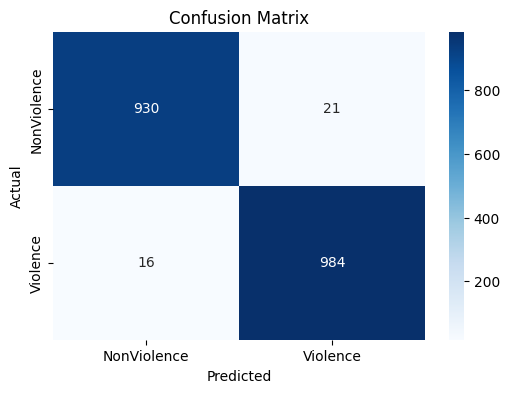

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
